# Core Distribution Samplers

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.utils import (
    sample_uniform_1d,
    sample_loguniform_1d,
    sample_gaussian_1d,
    sample_lognormal_1d,
    sample_powerlaw_1d,
    sample_maxwellian_1d,
    sample_beta_1d,
)
from gwGenealogy.utils import set_rcparams
import numpy as np
import matplotlib.pyplot as plt

set_rcparams()

lal.MSUN_SI != Msun


## Draw samples from all seven distributions

In [2]:
uniform   = sample_uniform_1d(5000, low=0, high=10, seed=0)
logunif   = sample_loguniform_1d(5000, low=1, high=1000, seed=1)
gauss     = sample_gaussian_1d(5000, mean=30, std=5, seed=2)
lognorm   = sample_lognormal_1d(5000, mean=1.0, sigma=0.5, seed=3)
powerlaw  = sample_powerlaw_1d(5000, beta=-2.35, xmin=5, xmax=100, seed=4)
maxwell   = sample_maxwellian_1d(5000, sigma=265, seed=5)
beta_samp = sample_beta_1d(5000, a=1.4, b=3.6, seed=6)

## Histograms

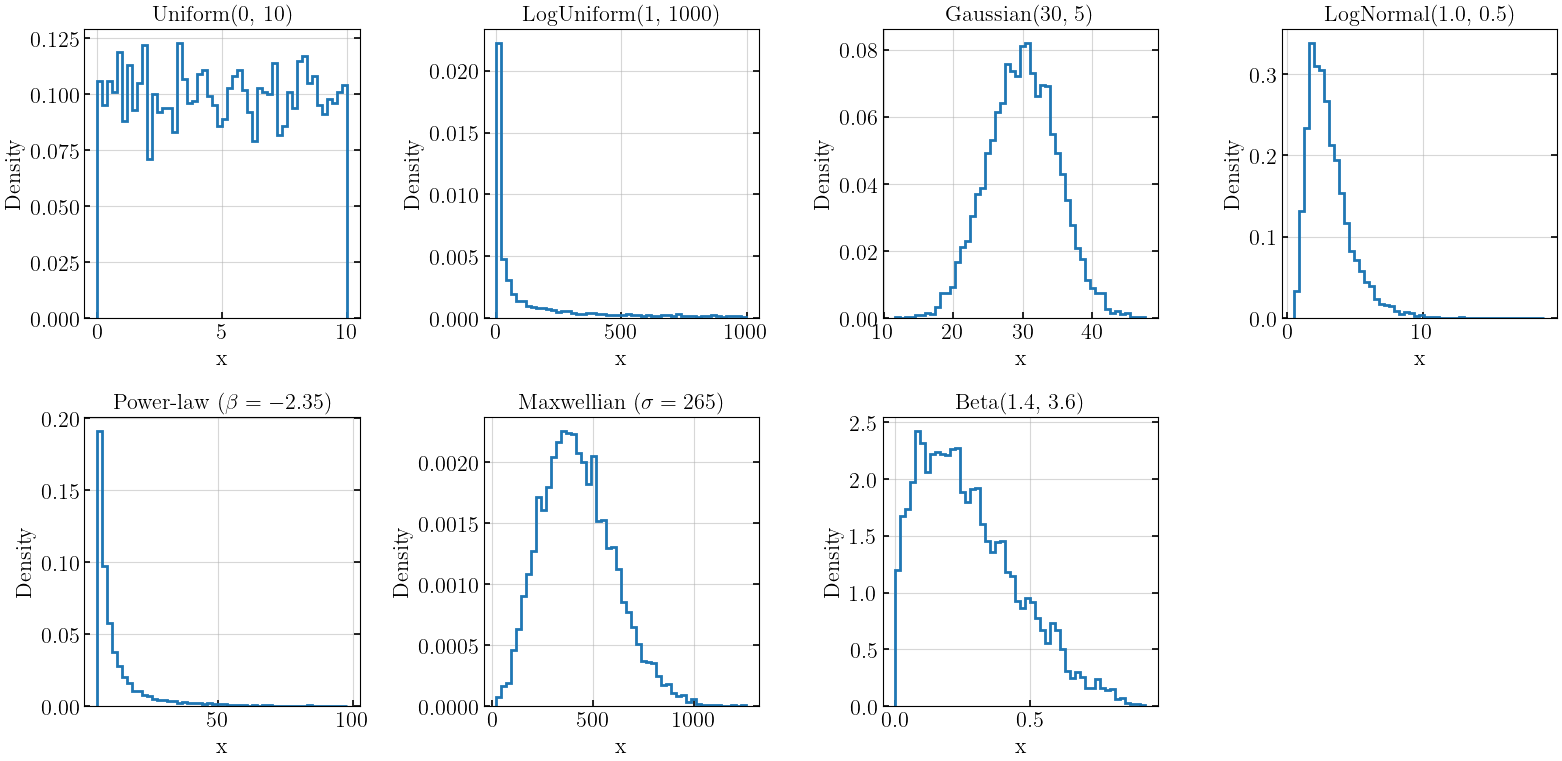

In [3]:
samples = [uniform, logunif, gauss, lognorm, powerlaw, maxwell, beta_samp]
titles  = ['Uniform(0, 10)', 'LogUniform(1, 1000)', 'Gaussian(30, 5)',
           'LogNormal(1.0, 0.5)', r'Power-law ($\beta=-2.35$)',
           r'Maxwellian ($\sigma=265$)', 'Beta(1.4, 3.6)']
xlabels = ['x', 'x', 'x', 'x', 'x', 'x', 'x']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, ax in enumerate(axes.flat[:7]):
    ax.hist(samples[idx], bins=50, density=True, histtype='step', lw=2)
    ax.set_title(titles[idx])
    ax.set_xlabel(xlabels[idx])
    ax.set_ylabel('Density')

axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

## JSD between distributions

In [4]:
from gwGenealogy.utils import compute_jensen_shannon_divergence

In [5]:
# Compare two power-law samples with different exponents
pl_a = sample_powerlaw_1d(5000, beta=-2.35, xmin=5, xmax=100, seed=10)
pl_b = sample_powerlaw_1d(5000, beta=-1.5,  xmin=5, xmax=100, seed=11)

jsd_pl = compute_jensen_shannon_divergence(pl_a, pl_b)
print(f"JSD(Power-law beta=-2.35 vs beta=-1.5) = {jsd_pl:.4f}")

JSD(Power-law beta=-2.35 vs beta=-1.5) = 0.0481


In [6]:
# Compare two beta distributions with different parameters
beta_a = sample_beta_1d(5000, a=1.4, b=3.6, seed=20)
beta_b = sample_beta_1d(5000, a=2.0, b=5.0, seed=21)

jsd_beta = compute_jensen_shannon_divergence(beta_a, beta_b)
print(f"JSD(Beta(1.4,3.6) vs Beta(2.0,5.0)) = {jsd_beta:.4f}")

JSD(Beta(1.4,3.6) vs Beta(2.0,5.0)) = 0.0136
